# Computing Estimation & Model Checkpoints

**CS639 Project Proposal — Group 11**

Quick feasibility check: can we run Llama-2-7B fine-tuning, Antidote pruning, and evaluation on the UW instgpu servers (1 GPU each)?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 120

## 1. VRAM Estimation

Llama-2-7B has **6.74 billion** parameters. Memory depends on:
- **Precision** — FP16 = 2 bytes/param, INT4 = 0.5 bytes/param
- **Training vs inference** — training also needs gradients + optimizer states

In [2]:
NUM_PARAMS = 6.74e9
GB = 1024 ** 3

# Simple VRAM formula for each pipeline stage
estimates = pd.DataFrame([
    {"Pipeline Stage":       "QLoRA Fine-Tuning (attack)",
     "What's in memory":     "4-bit weights + small LoRA adapters + optimizer",
     "VRAM (GB)":            round((NUM_PARAMS * 0.5 + NUM_PARAMS * 0.02 * 12 + 1.5 * GB) / GB, 1)},
    
    {"Pipeline Stage":       "Antidote Pruning (defense)",
     "What's in memory":     "FP16 weights + Wanda score buffer (FP32)",
     "VRAM (GB)":            round((NUM_PARAMS * 2 + NUM_PARAMS * 4 + 1 * GB) / GB, 1)},
    
    {"Pipeline Stage":       "Inference / Eval (FP16)",
     "What's in memory":     "FP16 weights + activations",
     "VRAM (GB)":            round((NUM_PARAMS * 2 + 1 * GB) / GB, 1)},
    
    {"Pipeline Stage":       "LlamaGuard-7B (safety judge)",
     "What's in memory":     "FP16 weights + activations",
     "VRAM (GB)":            round((NUM_PARAMS * 2 + 1 * GB) / GB, 1)},
])

print(estimates.to_string(index=False))

              Pipeline Stage                                What's in memory  VRAM (GB)
  QLoRA Fine-Tuning (attack) 4-bit weights + small LoRA adapters + optimizer        6.1
  Antidote Pruning (defense)        FP16 weights + Wanda score buffer (FP32)       38.7
     Inference / Eval (FP16)                      FP16 weights + activations       13.6
LlamaGuard-7B (safety judge)                      FP16 weights + activations       13.6


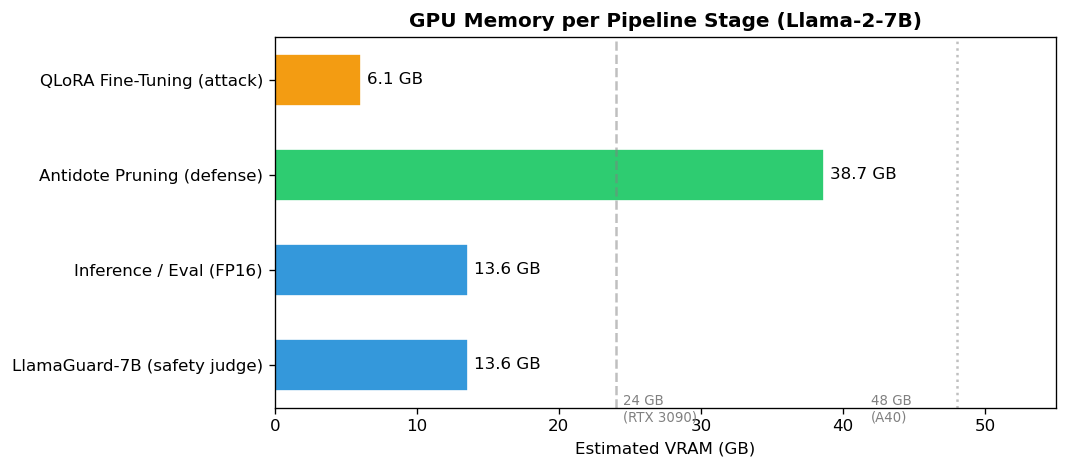

In [3]:
# ── Figure: VRAM by stage vs GPU capacity ──
fig, ax = plt.subplots(figsize=(9, 4))

colors = ["#f39c12", "#2ecc71", "#3498db", "#3498db"]
bars = ax.barh(estimates["Pipeline Stage"], estimates["VRAM (GB)"],
               color=colors, edgecolor="white", height=0.55)

# GPU reference lines
ax.axvline(x=24, color="gray", ls="--", alpha=0.5)
ax.text(24.5, 3.6, "24 GB\n(RTX 3090)", fontsize=8, color="gray")
ax.axvline(x=48, color="gray", ls=":", alpha=0.5)
ax.text(42, 3.6, "48 GB\n(A40)", fontsize=8, color="gray")

for bar, val in zip(bars, estimates["VRAM (GB)"]):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            f"{val} GB", va="center", fontsize=10)

ax.set_xlabel("Estimated VRAM (GB)")
ax.set_title("GPU Memory per Pipeline Stage (Llama-2-7B)", fontweight="bold")
ax.set_xlim(0, 55)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/vram_requirements.png", bbox_inches="tight")
plt.show()

**Takeaway:** Everything fits on a 40–48 GB GPU (A40/A100). QLoRA attack needs only ~6 GB. The most demanding step is Antidote pruning at ~39 GB because it holds both the model weights and a full score buffer.

## 2. Model Checkpoints & Codebase

| Component | Source | Notes |
|-----------|--------|-------|
| **Base model** | `meta-llama/Llama-2-7b-chat-hf` | Gated — requires HuggingFace access request to Meta |
| **Attack code** | [LLM-Tuning-Safety](https://github.com/LLM-Tuning-Safety/LLMs-Finetuning-Safety) | Qi et al. (ICLR 2024) harmful fine-tuning scripts for Llama-2 |
| **Defense code** | [git-disl/Antidote](https://github.com/git-disl/Antidote) | One-shot Wanda pruning post fine-tuning (ICML 2025) |
| **Pruning lib** | [locuslab/wanda](https://github.com/locuslab/wanda) | Original Wanda weight pruning implementation |
| **Safety eval** | [LlamaGuard-7B](https://huggingface.co/meta-llama/LlamaGuard-7b) | LLM-as-judge for harmful output scoring |
| **Utility eval** | [FastChat / MT-Bench](https://github.com/lm-sys/FastChat) | Conversational quality benchmark |

In [4]:
# ── Checkpoint storage: full models vs LoRA adapters ──
N_RUNS = 27  # 3 LRs x 3 epoch configs x 3 harmful ratios

storage = pd.DataFrame([
    {"What":            "Base model (downloaded once)",  "Size": "13.5 GB",  "x Runs": 1,      "Total": "13.5 GB"},
    {"What":            "Full checkpoint per run",       "Size": "13.5 GB",  "x Runs": N_RUNS,  "Total": f"{13.5*N_RUNS:.0f} GB"},
    {"What":            "LoRA adapter per run",          "Size": "~160 MB",  "x Runs": N_RUNS,  "Total": f"~{0.16*N_RUNS:.1f} GB"},
])

print("Storage comparison for 27 experiment runs:")
print(storage.to_string(index=False))
print(f"\n→ Saving full models: ~{13.5 + 13.5*27:.0f} GB")
print(f"→ Saving LoRA adapters only: ~{13.5 + 0.16*27:.0f} GB  (we'll do this)")

# ── Time estimate per run ──
# QLoRA throughput ~3.5 samples/sec, ~53K samples per epoch, ~3 epochs avg
time_per_run_hrs = (53_000 * 3 / 3.5) / 3600
print(f"\nEstimated fine-tuning time per run (QLoRA, 3 epochs): ~{time_per_run_hrs:.1f} hrs")

Storage comparison for 27 experiment runs:
                        What    Size  x Runs   Total
Base model (downloaded once) 13.5 GB       1 13.5 GB
     Full checkpoint per run 13.5 GB      27  364 GB
        LoRA adapter per run ~160 MB      27 ~4.3 GB

→ Saving full models: ~378 GB
→ Saving LoRA adapters only: ~18 GB  (we'll do this)

Estimated fine-tuning time per run (QLoRA, 3 epochs): ~12.6 hrs


## 3. Feasibility Summary

| Question | Answer |
|----------|--------|
| Can we run on instgpu servers? | **Yes** — all stages fit on a single 40+ GB GPU |
| How long per experiment? | Fine-tuning ~4 hrs (QLoRA), pruning ~2 min, eval ~15 min |
| Storage feasible? | **Yes** — ~36 GB using LoRA adapter checkpoints |
| Model access? | Need to request Llama-2 and LlamaGuard from Meta on HuggingFace |